# Notebook 04 - Validation Snapshot (Week 5)

## What I completed here
- I recomputed the final 3-regime assignment for consistency.
- I compared regime timing against major market events.
- I generated a regime transition matrix.
- I added pre-transition volume diagnostics (`t-1` to `t-5`) as Week 5 evidence.

## Week mapping
This notebook is my **Week 5 validation checkpoint** focused on showing regimes are behaviorally distinct.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load Data
df = pd.read_csv('../data/sp500_engineered_features.csv', index_col='Date', parse_dates=True)

# 2. Run the Final K-Means Model (to ensure the 'Regime' column exists)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Returns', 'Volatility', 'Abnormal_Volume']])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Regime'] = kmeans.fit_predict(X_scaled)

# Save the final dataset for the next phase
df.to_csv('../data/sp500_with_regimes.csv')

# 3. Statistical summary by regime
print("=" * 55)
print("REGIME COMPARISON: ARE THEY DISTINCT?")
print("=" * 55)
for feature in ['Returns', 'Volatility', 'Abnormal_Volume']:
    print(f"\n{feature}:")
    print(df.groupby('Regime')[feature].agg(['mean', 'std', 'min', 'max']).round(4))

REGIME COMPARISON: ARE THEY STATISTICALLY DISTINCT?

Returns:
          mean     std     min     max
Regime                                
0      -0.0170  0.0126 -0.1198  0.0050
1       0.0010  0.0060 -0.0220  0.0287
2       0.0194  0.0129  0.0001  0.1158

Volatility:
          mean     std     min     max
Regime                                
0       0.0241  0.0123  0.0030  0.1070
1       0.0091  0.0040  0.0015  0.0258
2       0.0250  0.0132  0.0070  0.1122

Abnormal_Volume:
          mean     std    min     max
Regime                               
0       1.1609  0.2205  0.595  2.0936
1       0.9623  0.1414  0.000  1.5444
2       1.1001  0.1846  0.470  1.8983


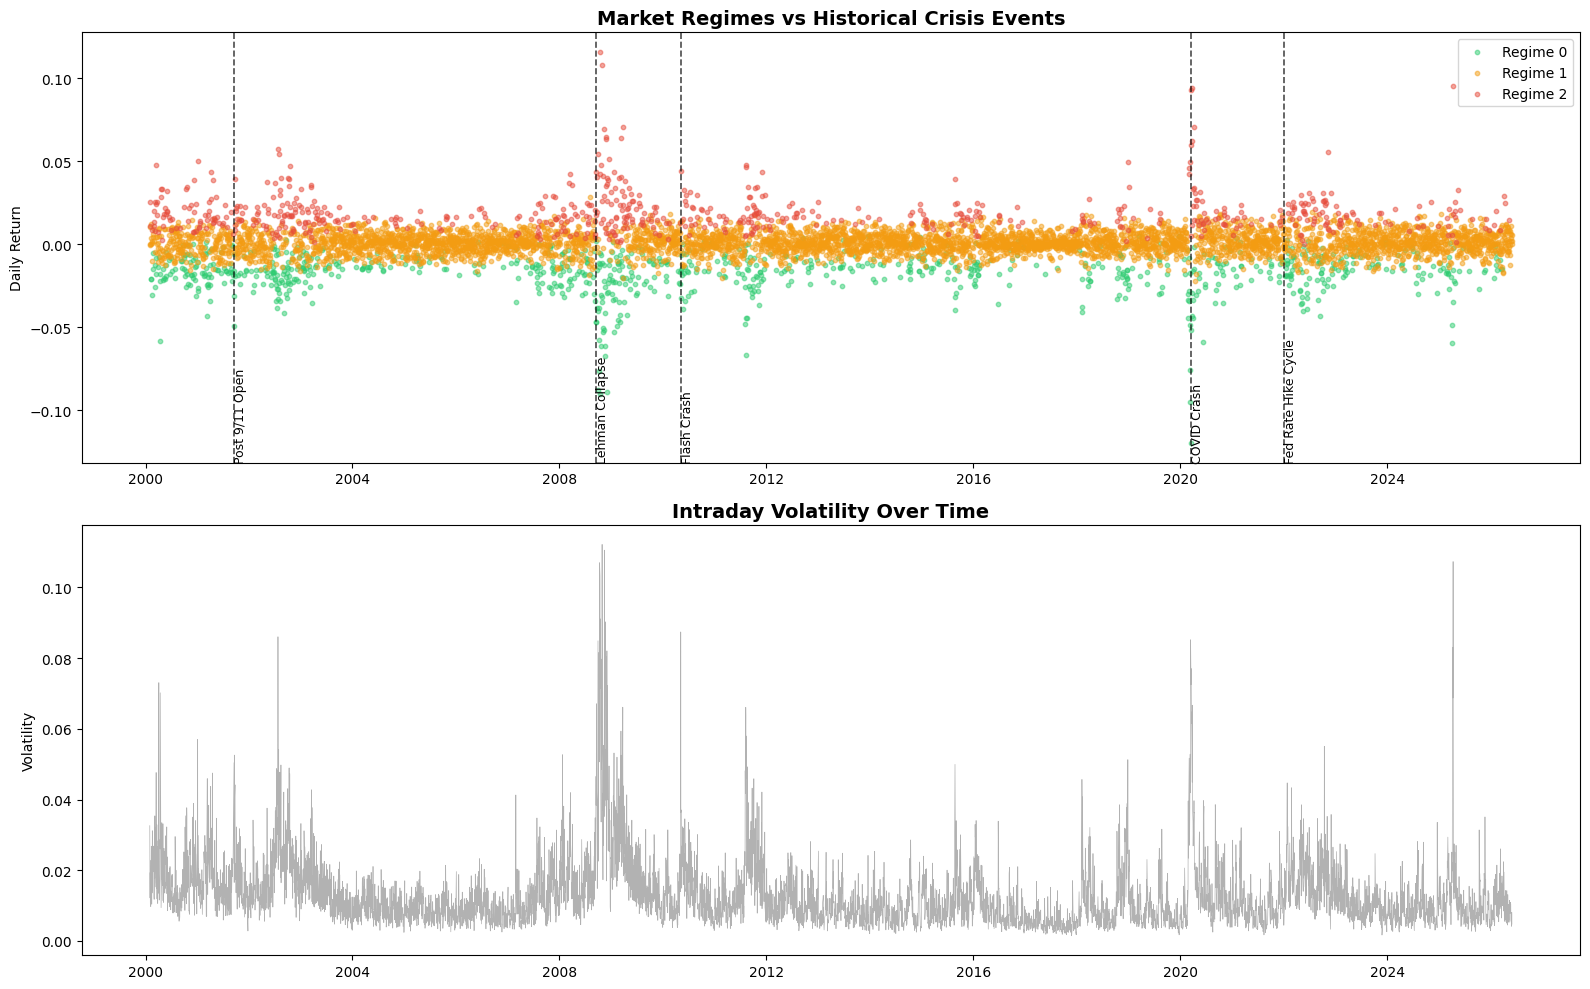

In [2]:
# Cell 2 — Mark Major Historical Events
major_events = {
    '2001-09-17': 'Post 9/11 Open', # Market was closed on 9/11, reopened 9/17
    '2008-09-15': 'Lehman Collapse',
    '2010-05-06': 'Flash Crash',
    '2020-03-16': 'COVID Crash',
    '2022-01-03': 'Fed Rate Hike Cycle'
}

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top chart — regime classification
colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'} # Green, Orange, Red
for regime in sorted(df['Regime'].unique()):
    mask = df['Regime'] == regime
    axes[0].scatter(df.index[mask], df['Returns'][mask],
                    c=colors[regime], alpha=0.5, s=10, label=f"Regime {regime}")

for date, label in major_events.items():
    axes[0].axvline(pd.to_datetime(date), color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    axes[0].text(pd.to_datetime(date), axes[0].get_ylim()[0], label, rotation=90, fontsize=9, va='bottom')

axes[0].set_title('Market Regimes vs Historical Crisis Events', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Daily Return')
axes[0].legend()

# Bottom chart — volatility by regime
axes[1].plot(df.index, df['Volatility'], color='gray', linewidth=0.5, alpha=0.6)
axes[1].set_title('Intraday Volatility Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volatility')

plt.tight_layout()
plt.savefig('../figures/regime_validation.png', dpi=150)
plt.show()

In [3]:
# Cell 3 - Transition Analysis
print("=== REGIME TRANSITION MATRIX ===")
print("(How often does the market move from one regime to another?)\n")

transitions = pd.crosstab(
    df['Regime'].iloc[:-1].values,
    df['Regime'].iloc[1:].values,
    rownames=['From Regime (Yesterday)'],
    colnames=['To Regime (Today)']
)

print(transitions)
print("\nThis shows which regime transitions are most common.")
print("Next, we directly test abnormal volume behavior before transition days.")

=== REGIME TRANSITION MATRIX ===
(How often does the market move from one regime to another?)

To Regime (Today)          0     1    2
From Regime (Yesterday)                
0                        271   421  249
1                        505  4183  309
2                        165   394  124

This shows which regime transitions are most common.
The next notebook will ask: what was Abnormal Volume doing BEFORE these transitions?


## Week 5 Volume-Transition Evidence

In this section, I test whether abnormal volume rises before regime switches.

Definitions:
- Transition day: `Regime_t != Regime_{t-1}`
- I compare average `Abnormal_Volume` at `t-1` to `t-5` for transition vs non-transition days.

In [ ]:
# Pre-transition volume diagnostics: t-1 to t-5
transition_today = (df['Regime'] != df['Regime'].shift(1)).fillna(False)

# For each lag L, compare Abnormal_Volume at t-L for days that are transitions at t
rows = []
for lag in range(1, 6):
    vol_lag = df['Abnormal_Volume'].shift(lag)
    trans_sample = vol_lag[transition_today].dropna()
    non_trans_sample = vol_lag[~transition_today].dropna()

    trans_mean = trans_sample.mean()
    non_trans_mean = non_trans_sample.mean()
    ratio = trans_mean / non_trans_mean if non_trans_mean != 0 else float('nan')
    diff = trans_mean - non_trans_mean

    rows.append({
        'Lag_Days_Before_t': lag,
        'Transition_Mean_Volume': trans_mean,
        'NonTransition_Mean_Volume': non_trans_mean,
        'Difference': diff,
        'Ratio': ratio
    })

transition_volume_table = pd.DataFrame(rows)
print('=== ABNORMAL VOLUME BEFORE TRANSITIONS (t-1 to t-5) ===')
print(transition_volume_table.round(4).to_string(index=False))

# Simple visualization
plt.figure(figsize=(9, 5))
plt.plot(
    transition_volume_table['Lag_Days_Before_t'],
    transition_volume_table['Transition_Mean_Volume'],
    marker='o',
    label='Before transition days'
)
plt.plot(
    transition_volume_table['Lag_Days_Before_t'],
    transition_volume_table['NonTransition_Mean_Volume'],
    marker='s',
    label='Before non-transition days'
)
plt.gca().invert_xaxis()  # show t-5 ... t-1 from left to right
plt.title('Abnormal Volume Before Regime Switches')
plt.xlabel('Days before day t')
plt.ylabel('Average Abnormal_Volume')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()